In [261]:
import IPython
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [262]:
from pathlib import Path
import importlib
import inspect
import sys

project_root = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import torch 
import numpy as np
import matplotlib.pyplot as plt
import scipy

import SPDE.Fokker_Planck_1D as fp1d
importlib.reload(fp1d)
FokkerPlanck1D = fp1d.FokkerPlanck1D


1D SDE Simulation- Ornstein–Uhlenbeck:

$dX = \theta (\mu - X(t)) dt + \sigma dW(t)$


In [263]:
def drift(t, x, params):
    theta = params[0]
    mu = params[1]
    return theta * (mu - x)

def diffusion(t, x, params):
    sigma = params[0]
    return sigma * torch.ones_like(x)

def simulate_ou(theta, mu, sigma=0.3, X0=1.0, T=20.0, dt=0.01, No_trajectories=1, only_final=False):
    M = No_trajectories
    N = int(T / dt)
    t = torch.linspace(0, T, N + 1)
    X = torch.zeros(N + 1)
    X[0] = X0

    if M == 1:  

        for n in range(N):
            dW = dt**0.5 * torch.randn(())
            X[n + 1] = X[n] + drift(t[n], X[n], [theta, mu]) * dt + diffusion(t[n], X[n], [sigma]) * dW
        output = (t, X)

    elif only_final==False: 
        X_ensemble = torch.zeros((M, N + 1))
        X_ensemble[:, 0] = X0 * torch.ones(M)
        for n in range(N):
            dW = dt**0.5 * torch.randn(M)
            X_ensemble[:, n + 1] = X_ensemble[:, n] + drift(t[n], X_ensemble[:, n], [theta, mu]) * dt + diffusion(t[n], X_ensemble[:, n], [sigma]) * dW
            
        output = (t, X_ensemble)

    elif only_final==True:
        
        X_ensemble = X0 * torch.ones(M)
        for n in range(N):
            dW = dt**0.5 * torch.randn(M)
            X_ensemble = X_ensemble + drift(t[n], X_ensemble, [theta, mu]) * dt + diffusion(t[n], X_ensemble, [sigma]) * dW
            
        output = (t, X_ensemble)

    return output

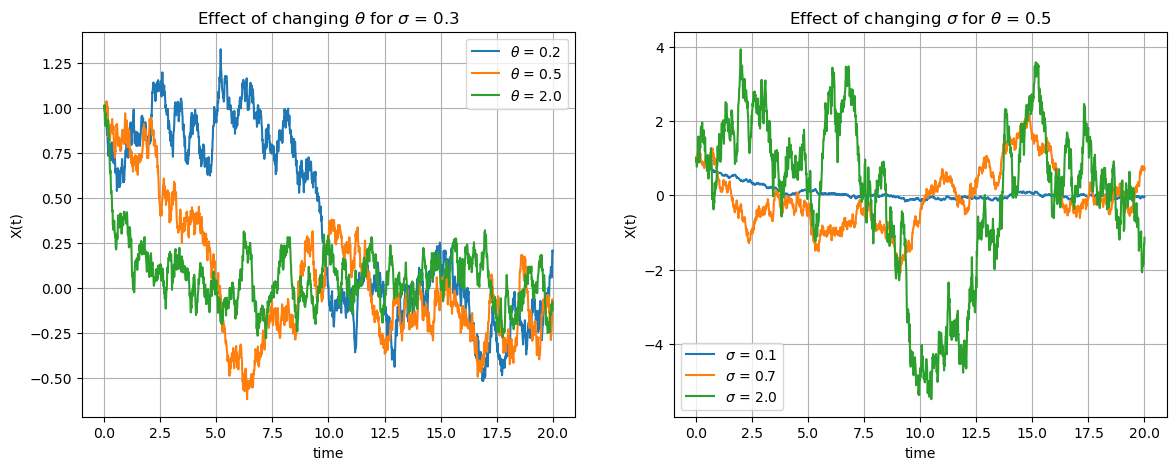

In [264]:
# Parameters for the Ornstein-Uhlenbeck process
params1 = [{"mu":0.0, "theta":0.2, "sigma":0.3},
           {"mu":0.0, "theta":0.5, "sigma":0.3},
           {"mu":0.0, "theta":2.0, "sigma":0.3},
           {"mu":0.0, "theta":0.5, "sigma":0.1},
           {"mu":0.0, "theta":0.5, "sigma":0.7},
           {"mu":0.0, "theta":0.5, "sigma":2.0},]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, param in enumerate(params1):
    t, X = simulate_ou(theta=param["theta"], mu=param["mu"], sigma=param["sigma"])

    if i<=2:
        axes[0].plot(t, X, label=f"$\\theta$ = {param['theta']}")

    if i>2:
        axes[1].plot(t, X, label=f"$\sigma$ = {param['sigma']}")


axes[0].set_title("Effect of changing $\\theta$ for"+" $\sigma$ = 0.3")
axes[0].set_xlabel("time")
axes[0].set_ylabel("X(t)")
axes[0].legend()
axes[0].grid(True)
axes[1].set_title("Effect of changing $\\sigma$ for"+" $\\theta$ = 0.5")
axes[1].set_xlabel("time")
axes[1].set_ylabel("X(t)")
axes[1].legend()
axes[1].grid(True)

plt.show()


Validation

In [265]:
# simulation Parameters

mu = 2.5
theta = 0.25
sigma = 1.0

Long-term distribution and Ensemble samples

Time-averaged mean: 2.4335
Time-averaged variance: 2.1676
Ensemble-averaged mean: 2.5149
Ensemble-averaged variance: 1.9900


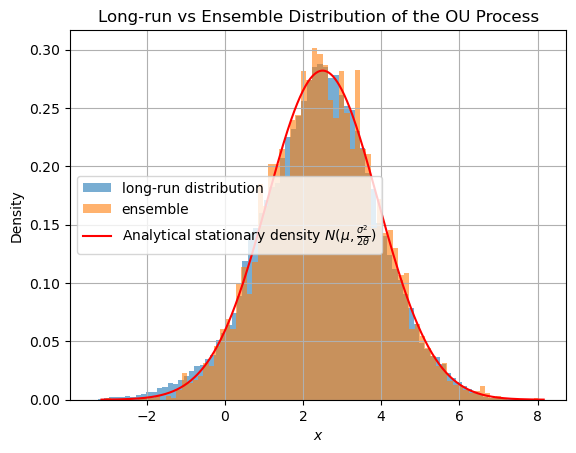

In [266]:
# Long-run Simulation

burn_in_time = 1000.0
dt = 0.01
burn_in_steps = int(burn_in_time / dt)

t, X = simulate_ou(theta=theta, mu=mu, sigma=sigma, T=burn_in_time + 2000.0, dt=dt)

t_stationary = t[burn_in_steps:]
X_stationary = X[burn_in_steps:]

time_averaged_mean = torch.mean(X_stationary)
time_averaged_variance = torch.var(X_stationary)

print(f"Time-averaged mean: {time_averaged_mean:.4f}")
print(f"Time-averaged variance: {time_averaged_variance:.4f}")

plt.hist(
    X_stationary,
    bins=80,
    density=True,
    alpha=0.6,
    label="long-run distribution"
)


# Ensemble samples

t, X_ensemble = simulate_ou(theta=theta, mu=mu, sigma=sigma, T=burn_in_time + 100.0, dt=dt, No_trajectories=5000, only_final=True)
x_ensemble_sample = X_ensemble
ensemble_averaged_mean = torch.mean(x_ensemble_sample)
ensemble_averaged_variance = torch.var(x_ensemble_sample)
print(f"Ensemble-averaged mean: {ensemble_averaged_mean:.4f}")
print(f"Ensemble-averaged variance: {ensemble_averaged_variance:.4f}")


plt.hist(
    x_ensemble_sample,
    bins=80,
    density=True,
    alpha=0.6,
    label="ensemble"
)


# Analytical stationary distribution

x_grid = np.linspace(
    mu - 4 * sigma/np.sqrt(2*theta),
    mu + 4 * sigma/np.sqrt(2*theta),
    500
)

stationary_pdf = np.sqrt(theta / (np.pi * sigma**2)) * np.exp(-theta * (x_grid - mu)**2 / sigma**2)

plt.plot(x_grid, stationary_pdf, label=["Analytical stationary density "+"$N(\\mu,\\frac{\\sigma^2}{2\\theta})$"], color="red")

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title("Long-run vs Ensemble Distribution of the OU Process")
plt.legend()
plt.grid(True)
plt.show()


Fokker-Planck equation 

In [267]:

# Spatial Domain
x_min = -5.0
x_max = 10.0
N_x = 100
dx = (x_max - x_min) / (N_x - 1)

# Temporal Domain
Time =50.0
dt = 0.001

# Initial Condition Parameters
mean_0 = 0.0
std_0 = 1.0

Drift = {"function": drift, "params": [theta, mu]}
Diffusion = {"function": diffusion, "params": [sigma]}

print(inspect.signature(FokkerPlanck1D.__init__))

fokker_planck_solver = FokkerPlanck1D(drift = Drift, diffusion = Diffusion, range_x = [x_min, x_max], num_points=N_x, T = Time, dt  = dt , mean_0 = mean_0, std_0 = std_0)



t, x, p = fokker_planck_solver.solve()


mass = torch.sum(p * dx, dim=1)
print(f"Mass at initial time: {mass[0]:.6f}")
print(f"Mass at final time: {mass[-1]:.6f}")




(self, drift, diffusion, range_x=(-10, 10), num_points=1000, T=10.0, dt=0.01, mean_0=0.0, std_0=1.0)
ODE solution completed.
Mass at initial time: 1.000001
Mass at final time: 1.000070


In [268]:
print(f"Shape of x: {x.shape}")
print(f"Shape of p: {p.shape}")
print(f"Shape of t: {t.shape}")

Shape of x: torch.Size([100])
Shape of p: torch.Size([50001, 100])
Shape of t: torch.Size([50001])


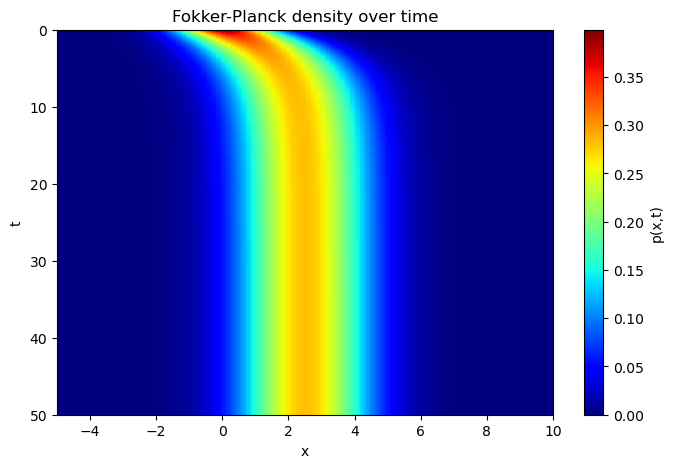

In [269]:
t_np = t.detach().cpu().numpy()
x_np = x.detach().cpu().numpy()
p_np = p.detach().cpu().numpy()

plt.figure(figsize=(8, 5))

plt.imshow(
    p.detach().cpu().numpy(),
    extent=[
        x[0].item(),
        x[-1].item(),
        t[-1].item(),
        t[0].item()
    ],
    aspect="auto", cmap="jet"
)

plt.colorbar(label="p(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Fokker-Planck density over time")
plt.show()

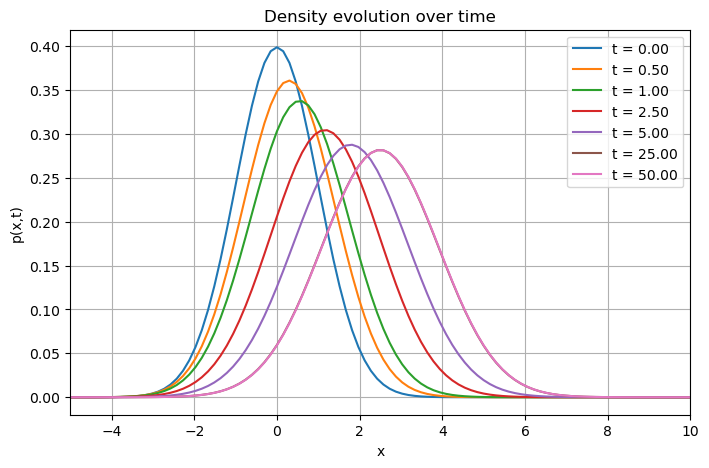

In [270]:
plt.figure(figsize=(8, 5))

time_indices = [0, len(t)//100, 2*len(t)//100, len(t)//20, len(t)//10, 5*len(t)//10, -1]

for idx in time_indices:
    plt.plot(
        x.detach().cpu().numpy(),
        p[idx].detach().cpu().numpy(),
        label=f"t = {t[idx].item():.2f}"
    )
plt.xlim(x_min, x_max)
plt.xlabel("x")
plt.ylabel("p(x,t)")
plt.title("Density evolution over time")
plt.legend()
plt.grid(True)
plt.show()

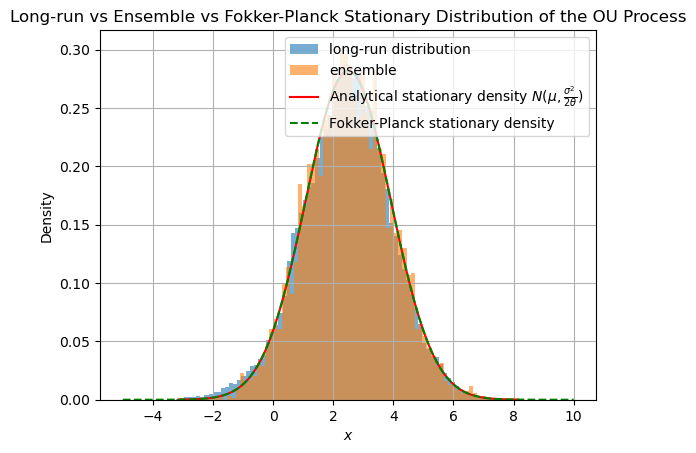

In [271]:
# Comparison of long-run distribution, ensemble distribution, and Fokker-Planck stationary distribution

plt.hist(
    X_stationary,
    bins=80,
    density=True,
    alpha=0.6,
    label="long-run distribution"
)

plt.hist(
    x_ensemble_sample,
    bins=80,
    density=True,
    alpha=0.6,
    label="ensemble"
)

plt.plot(x_grid, stationary_pdf, label=["Analytical stationary density "+"$N(\\mu,\\frac{\\sigma^2}{2\\theta})$"], color="red")

plt.plot(x_np, p_np[-1], label="Fokker-Planck stationary density", color="green", linestyle="--")

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title("Long-run vs Ensemble vs Fokker-Planck Stationary Distribution of the OU Process")
plt.legend()
plt.grid(True)
plt.show()







